## Descriptive Analytics for Numerical Columns

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [75]:
data=pd.read_csv('sales_data_with_discounts.csv')
data.head()

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770


In [4]:
num_cols=data.select_dtypes(include=['int64','float64']).columns
num_cols.to_list()

['Volume',
 'Avg Price',
 'Total Sales Value',
 'Discount Rate (%)',
 'Discount Amount',
 'Net Sales Value']

In [6]:
mean_vals = data[num_cols].mean()
median_vals = data[num_cols].median()
mode_vals = data[num_cols].mode().iloc[0]  # mode() can return multiple rows
std_vals = data[num_cols].std()

print("\nMean:\n", mean_vals)
print("\nMedian:\n", median_vals)
print("\nMode:\n", mode_vals)
print("\nStandard Deviation:\n", std_vals)



Mean:
 Volume                   5.066667
Avg Price            10453.433333
Total Sales Value    33812.835556
Discount Rate (%)       15.155242
Discount Amount       3346.499424
Net Sales Value      30466.336131
dtype: float64

Median:
 Volume                  4.000000
Avg Price            1450.000000
Total Sales Value    5700.000000
Discount Rate (%)      16.577766
Discount Amount       988.933733
Net Sales Value      4677.788059
dtype: float64

Mode:
 Volume                   3.000000
Avg Price              400.000000
Total Sales Value    24300.000000
Discount Rate (%)        5.007822
Discount Amount         69.177942
Net Sales Value        326.974801
Name: 0, dtype: float64

Standard Deviation:
 Volume                   4.231602
Avg Price            18079.904840
Total Sales Value    50535.074173
Discount Rate (%)        4.220602
Discount Amount       4509.902963
Net Sales Value      46358.656624
dtype: float64


'''Volume → Moderate variability
Avg Price → Very high variability
Total Sales Value → Very high variability
Discount Rate (%) → Low/moderate variability
Discount Amount → High variability
Net Sales Value → Very high variability'''

## Data Visualization

In [42]:
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
cat_cols = data.select_dtypes(include=['object', 'category']).columns



Index(['Date', 'Day', 'SKU', 'City', 'BU', 'Brand', 'Model'], dtype='object')

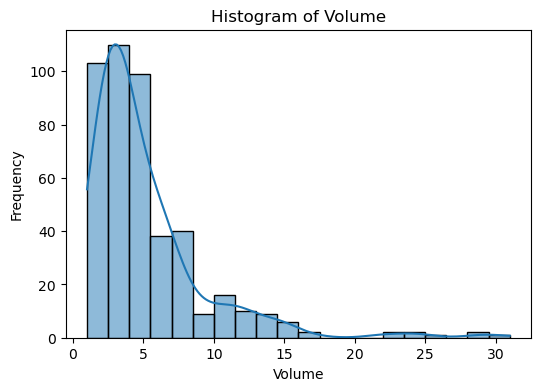

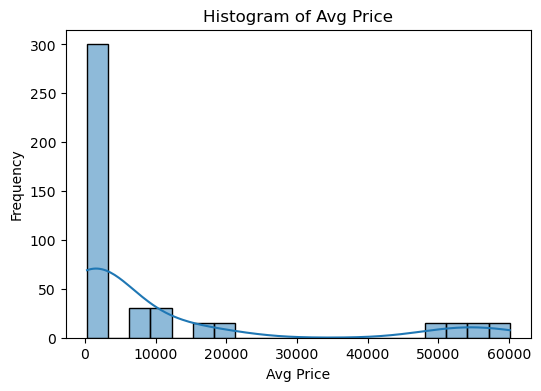

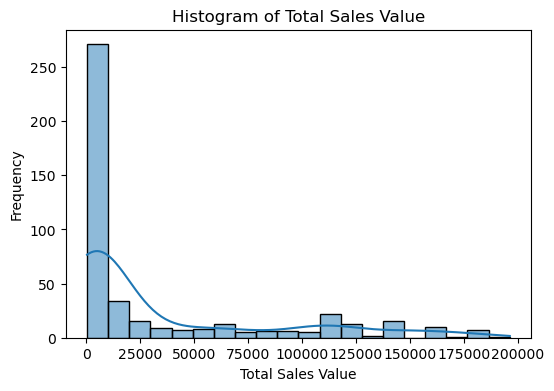

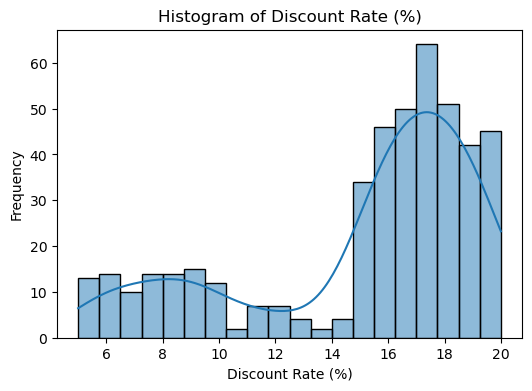

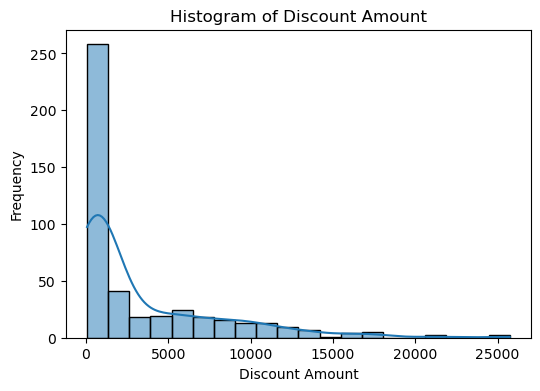

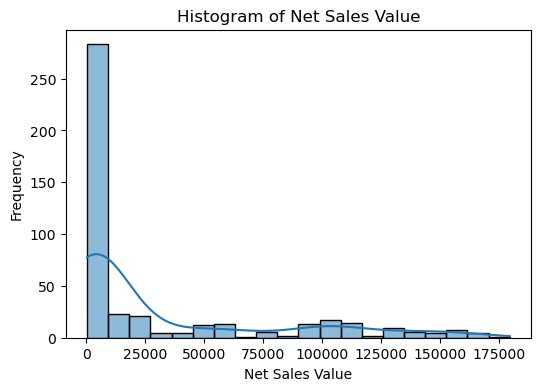

In [18]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(data[col], kde=True, bins=20)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

Inference:
Volume, Avg Price, Total Sales Value, Discount Amount, Net Sales Value:Right-skewed
Most values low,Few high extremes
Discount Rate:Slightly left-skewed

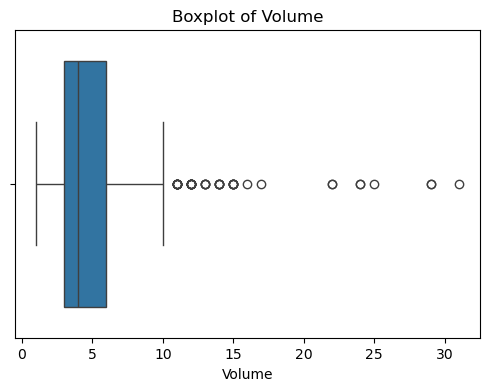

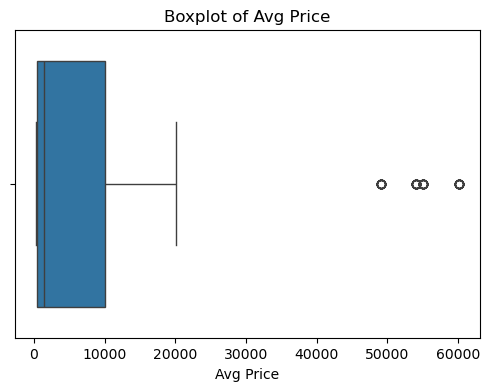

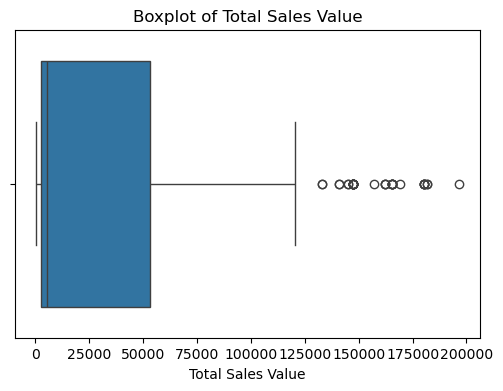

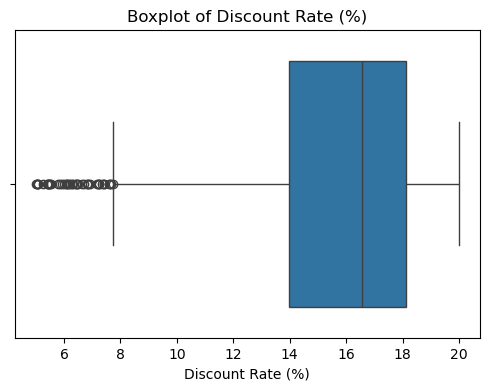

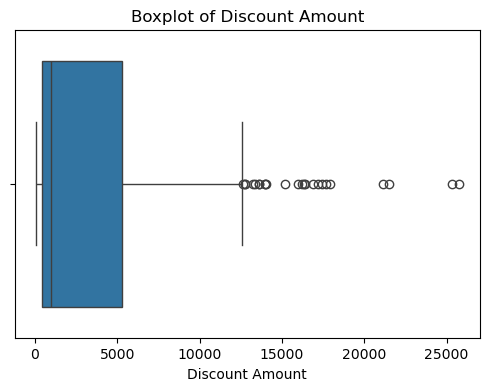

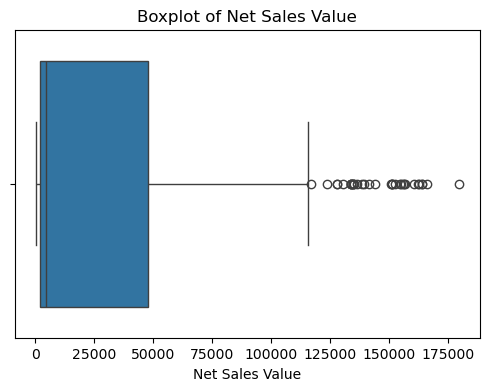

In [22]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=data[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

Inference:
Volume, Avg Price, Total Sales Value, Discount Amount, Net Sales Value: Right-skewed,
Most values low,Few high extremes,Presence of upper outliers
Discount Rate:Slightly left-skewed,Values clustered around median, few outliers

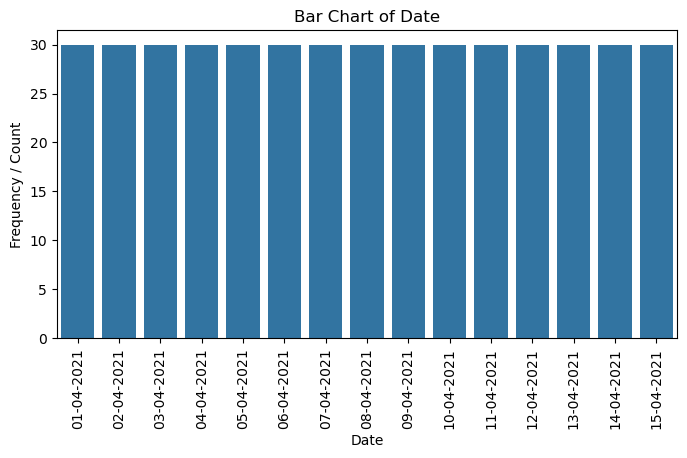

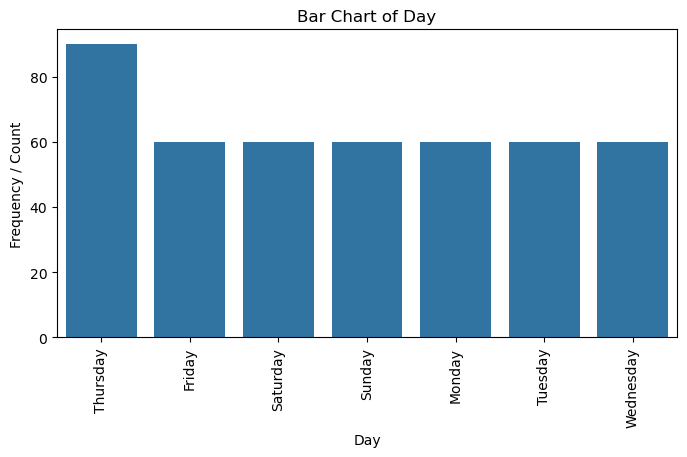

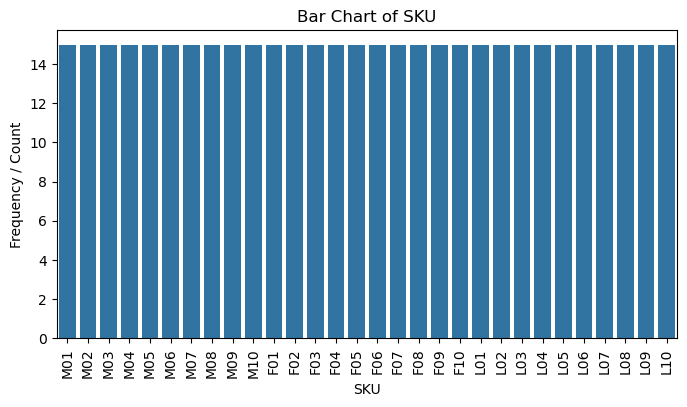

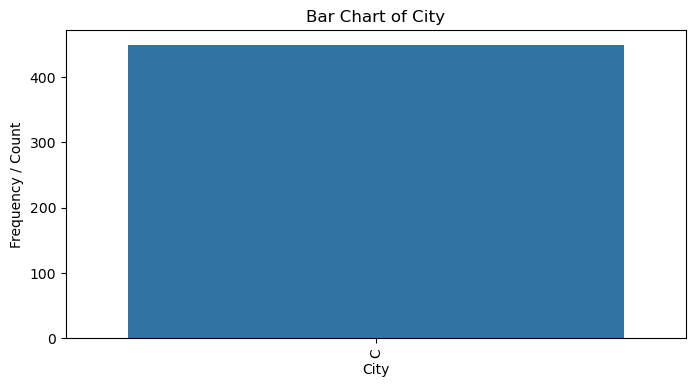

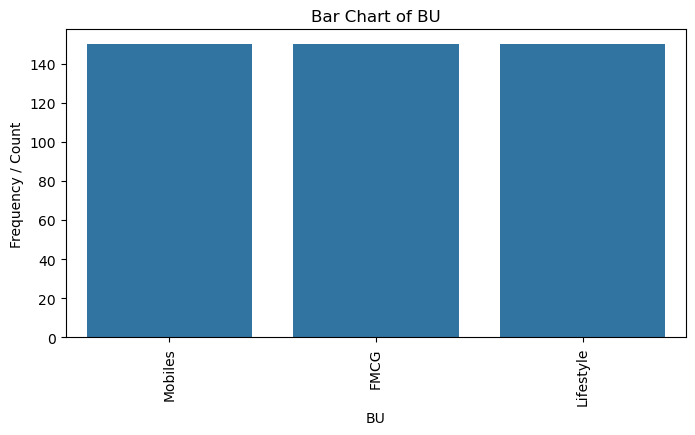

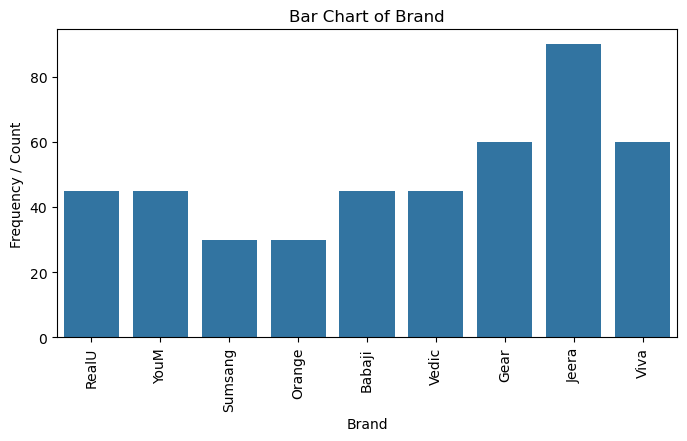

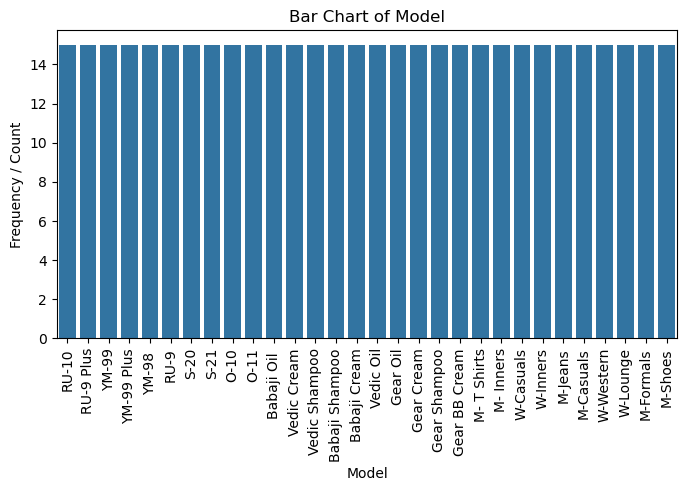

In [39]:
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, data=data)
    plt.title(f"Bar Chart of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency / Count")
    plt.xticks(rotation=90)
    plt.show()

Insight:
All business units, SKUs, models, and dates have an even distribution, showing balanced data.
Thursday is much higher in frequency than other days, which are all equal.
Only one city ("C") is present in the data.
Brand has a skewed distribution: "Jeera," "Gear," and "Viva" are most frequent, while "Sumsang" and "Orange" are lowest.

## Standardization of Numerical Variables

In [57]:
from sklearn.preprocessing import StandardScaler

In [59]:
scaler=StandardScaler()

In [60]:
data_scaled=data.copy()

In [61]:
data_scaled[num_cols]=scaler.fit_transform(data[num_cols])

In [62]:
data[num_cols].head()

,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,15,12100,181500,11.654820,21153.498820,160346.501180
1,10,10100,101000,11.560498,11676.102961,89323.897039
2,7,16100,112700,9.456886,10657.910157,102042.089843
3,6,20100,120600,6.935385,8364.074702,112235.925298
4,3,8100,24300,17.995663,4372.946230,19927.053770


In [63]:
data_scaled[num_cols].head()

,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,2.350029,0.091173,2.925721,-0.830289,3.952816,2.804756
1,1.167129,-0.019570,1.330995,-0.852661,1.849014,1.271026
2,0.457388,0.312659,1.562775,-1.351631,1.622995,1.545675
3,0.220808,0.534146,1.719276,-1.949723,1.113807,1.765810
4,-0.488932,-0.130313,-0.188452,0.673739,0.227852,-0.227595


Standardization rescales numerical features to a common scale, improves ML model performance, ensures fair contribution of each feature, and maintains the distribution shape.

## Conversion of Categorical Data into Dummy Variables

In [65]:
from sklearn.preprocessing import OneHotEncoder

In [66]:
ohe=OneHotEncoder()
enc_values=ohe.fit_transform(data[['Date', 'Day', 'SKU', 'City', 'BU', 'Brand', 'Model']]).toarray()
enc_values

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 1., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [67]:
encoded_columns=ohe.get_feature_names_out()
encoded_columns

array(['Date_01-04-2021', 'Date_02-04-2021', 'Date_03-04-2021',
       'Date_04-04-2021', 'Date_05-04-2021', 'Date_06-04-2021',
       'Date_07-04-2021', 'Date_08-04-2021', 'Date_09-04-2021',
       'Date_10-04-2021', 'Date_11-04-2021', 'Date_12-04-2021',
       'Date_13-04-2021', 'Date_14-04-2021', 'Date_15-04-2021',
       'Day_Friday', 'Day_Monday', 'Day_Saturday', 'Day_Sunday',
       'Day_Thursday', 'Day_Tuesday', 'Day_Wednesday', 'SKU_F01',
       'SKU_F02', 'SKU_F03', 'SKU_F04', 'SKU_F05', 'SKU_F06', 'SKU_F07',
       'SKU_F08', 'SKU_F09', 'SKU_F10', 'SKU_L01', 'SKU_L02', 'SKU_L03',
       'SKU_L04', 'SKU_L05', 'SKU_L06', 'SKU_L07', 'SKU_L08', 'SKU_L09',
       'SKU_L10', 'SKU_M01', 'SKU_M02', 'SKU_M03', 'SKU_M04', 'SKU_M05',
       'SKU_M06', 'SKU_M07', 'SKU_M08', 'SKU_M09', 'SKU_M10', 'City_C',
       'BU_FMCG', 'BU_Lifestyle', 'BU_Mobiles', 'Brand_Babaji',
       'Brand_Gear', 'Brand_Jeera', 'Brand_Orange', 'Brand_RealU',
       'Brand_Sumsang', 'Brand_Vedic', 'Brand_Viva', '

In [68]:
# encoded_columns from OneHotEncoder
total_encoded_cols = len(encoded_columns)
total_encoded_cols

95

In [72]:
data_num=data_scaled.drop(columns=cat_cols)

In [73]:
data_final=pd.concat([data_num,enc_df],axis=1)
data_final.head()

,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value,Date_01-04-2021,Date_02-04-2021,Date_03-04-2021,Date_04-04-2021,...,Model_Vedic Cream,Model_Vedic Oil,Model_Vedic Shampoo,Model_W-Casuals,Model_W-Inners,Model_W-Lounge,Model_W-Western,Model_YM-98,Model_YM-99,Model_YM-99 Plus
0,2.350029,0.091173,2.925721,-0.830289,3.952816,2.804756,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.167129,-0.019570,1.330995,-0.852661,1.849014,1.271026,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.457388,0.312659,1.562775,-1.351631,1.622995,1.545675,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.220808,0.534146,1.719276,-1.949723,1.113807,1.765810,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.488932,-0.130313,-0.188452,0.673739,0.227852,-0.227595,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


Summary of Key Findings:
Most numerical variables (Volume, Avg Price, Total Sales Value, Discount Amount, Net Sales Value) are right-skewed with several high-value outliers, while Discount Rate (%) is fairly balanced. Histograms and boxplots revealed uneven distributions, clusters, and extreme values in the data.

Importance of Preprocessing:
Steps like standardization and one-hot encoding are crucial to make data suitable for ML models: standardization scales numeric features for fair comparison, and one-hot encoding converts categorical variables into numeric format, enabling algorithms to process them correctly.